# Sign Language LSTM — Training Notebook

**Pipeline:** `.npy` sequences → preprocessing → LSTM → evaluation

Run the cells in order after collecting data with `collect_data.py`.

In [1]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization # type: ignore
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau # type: ignore
from tensorflow.keras.optimizers import Adam # type: ignore
from tensorflow.keras.utils import to_categorical # type: ignore

print('TF version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))


TF version: 2.15.0
GPU: []


## 1. Load Dataset

In [2]:
DATASET_DIR = 'dataset'
SEQUENCE_LENGTH = 30

def load_dataset(dataset_dir, seq_len=30):
    X, y = [], []
    words = sorted(d for d in os.listdir(dataset_dir)
                   if os.path.isdir(os.path.join(dataset_dir, d)))
    print('Words found:', words)
    for word in words:
        word_dir = os.path.join(dataset_dir, word)
        seqs = sorted(d for d in os.listdir(word_dir)
                      if os.path.isdir(os.path.join(word_dir, d)))
        for seq_id in seqs:
            seq_dir = os.path.join(word_dir, seq_id)
            frames = []
            for fi in range(seq_len):
                p = os.path.join(seq_dir, f'{fi}.npy')
                frames.append(np.load(p) if os.path.exists(p) else np.zeros(63))
            if len(frames) == seq_len:
                X.append(frames)
                y.append(word)
        print(f'  {word}: {len(seqs)} sequences')
    return np.array(X, dtype=np.float32), np.array(y), words

X, y_raw, words = load_dataset(DATASET_DIR, SEQUENCE_LENGTH)
print(f'\nTotal: {len(X)} sequences | Shape: {X.shape}')

Words found: ['I', 'can', 'goodbye', 'hello', 'help', 'more', 'no', 'please', 'sorry', 'stop', 'thankyou', 'we', 'yes', 'you']
  I: 30 sequences
  can: 30 sequences
  goodbye: 30 sequences
  hello: 30 sequences
  help: 30 sequences
  more: 30 sequences
  no: 30 sequences
  please: 30 sequences
  sorry: 30 sequences
  stop: 30 sequences
  thankyou: 30 sequences
  we: 30 sequences
  yes: 30 sequences
  you: 30 sequences

Total: 420 sequences | Shape: (420, 30, 126)


## 2. Normalize & Encode Labels

In [3]:
# Normalize
norms = np.linalg.norm(X, axis=-1, keepdims=True)
norms = np.where(norms == 0, 1, norms)
X = X / norms

# Encode labels
le = LabelEncoder()
y_int = le.fit_transform(y_raw)
y_cat = to_categorical(y_int, num_classes=len(words))

# Train/test split
X_train, X_test, y_train, y_test, yi_train, yi_test = train_test_split(
    X, y_cat, y_int, test_size=0.2, random_state=42, stratify=y_int
)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print('Classes:', list(le.classes_))

Train: (336, 30, 126) | Test: (84, 30, 126)
Classes: ['I', 'can', 'goodbye', 'hello', 'help', 'more', 'no', 'please', 'sorry', 'stop', 'thankyou', 'we', 'yes', 'you']


## 3. Build LSTM Model

In [4]:
num_classes = len(words)

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(30, 126),
         dropout=0.2, recurrent_dropout=0.2),
    BatchNormalization(),
    LSTM(64, return_sequences=False, dropout=0.2, recurrent_dropout=0.2),
    BatchNormalization(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax'),
], name='SignLanguageLSTM')

model.compile(
    optimizer=Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


Model: "SignLanguageLSTM"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 30, 64)            48896     
                                                                 
 batch_normalization (Batch  (None, 30, 64)            256       
 Normalization)                                                  
                                                                 
 lstm_1 (LSTM)               (None, 64)                33024     
                                                                 
 batch_normalization_1 (Bat  (None, 64)                256       
 chNormalization)                                                
                                                                 
 dense (Dense)               (None, 64)                4160      
                                                                 
 dropout (Dropout)           (None, 64)          

## 4. Train

In [5]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-6, verbose=1),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/50


21/21 [==============================] - 9s 61ms/step - loss: 2.3641 - accuracy: 0.2560 - val_loss: 2.5773 - val_accuracy: 0.4524 - lr: 0.0010
Epoch 2/50
21/21 [==============================] - 1s 26ms/step - loss: 1.7163 - accuracy: 0.4911 - val_loss: 2.5073 - val_accuracy: 0.5595 - lr: 0.0010
Epoch 3/50
21/21 [==============================] - 1s 25ms/step - loss: 1.3749 - accuracy: 0.6131 - val_loss: 2.4070 - val_accuracy: 0.6190 - lr: 0.0010
Epoch 4/50
21/21 [==============================] - 1s 28ms/step - loss: 1.1452 - accuracy: 0.6607 - val_loss: 2.2770 - val_accuracy: 0.6071 - lr: 0.0010
Epoch 5/50
21/21 [==============================] - 1s 28ms/step - loss: 0.8966 - accuracy: 0.7440 - val_loss: 2.1255 - val_accuracy: 0.7738 - lr: 0.0010
Epoch 6/50
21/21 [==============================] - 1s 29ms/step - loss: 0.7309 - accuracy: 0.8095 - val_loss: 1.9290 - val_accuracy: 0.7976 - lr: 0.0010
Epoch 7/50
21/21 [==============================] - 1s 26ms/step - loss: 0

## 5. Evaluate

Test accuracy: 100.00%  |  Loss: 0.0056


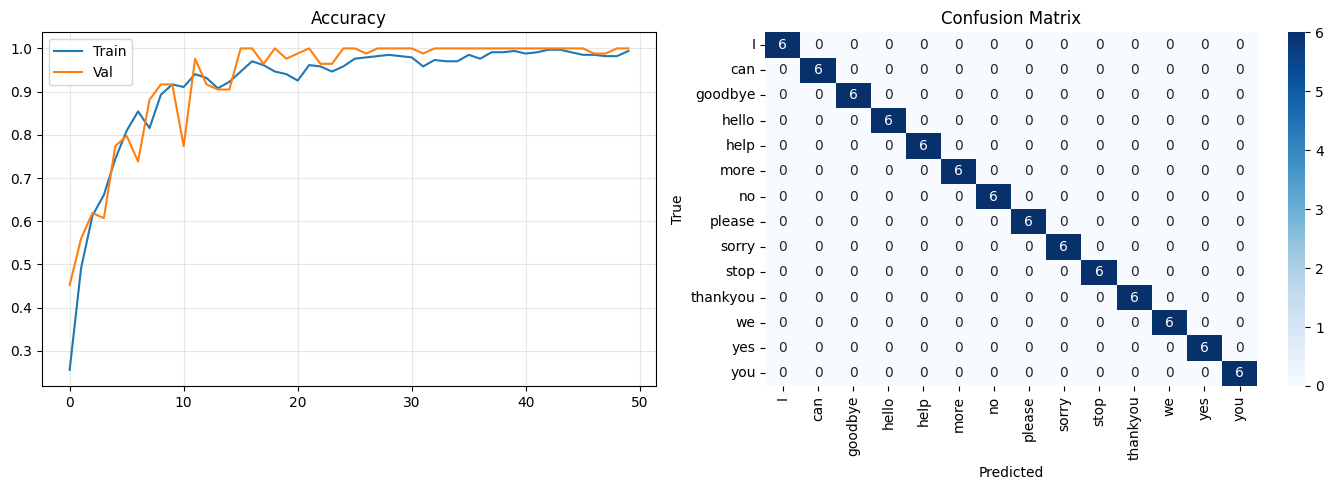


Classification Report:
              precision    recall  f1-score   support

           I       1.00      1.00      1.00         6
         can       1.00      1.00      1.00         6
     goodbye       1.00      1.00      1.00         6
       hello       1.00      1.00      1.00         6
        help       1.00      1.00      1.00         6
        more       1.00      1.00      1.00         6
          no       1.00      1.00      1.00         6
      please       1.00      1.00      1.00         6
       sorry       1.00      1.00      1.00         6
        stop       1.00      1.00      1.00         6
    thankyou       1.00      1.00      1.00         6
          we       1.00      1.00      1.00         6
         yes       1.00      1.00      1.00         6
         you       1.00      1.00      1.00         6

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



In [6]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy: {acc*100:.2f}%  |  Loss: {loss:.4f}')

# Confusion matrix
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
cm = confusion_matrix(yi_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)

sns.heatmap(cm, annot=True, fmt='d', xticklabels=words,
            yticklabels=words, ax=axes[1], cmap='Blues')
axes[1].set_title('Confusion Matrix')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout(); plt.show()

print('\nClassification Report:')
print(classification_report(yi_test, y_pred, target_names=words))

## 6. Save Model

In [7]:
os.makedirs('models', exist_ok=True)
model.save('models/sign_model.keras')

label_map = {int(i): w for i, w in enumerate(le.classes_)}
meta = {
    'sequence_length': 30,
    'feature_dim': 126,
    'num_classes': num_classes,
    'label_map': label_map,
    'test_accuracy': float(acc),
}
with open('models/model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Model saved to models/sign_model.keras')
print('Metadata saved to models/model_meta.json')

Model saved to models/sign_model.keras
Metadata saved to models/model_meta.json
